# Build and Test Clustering 

Using subject (genre), category, page counts, published date

#### Imports and Data 

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/books.csv")
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")
print(df.shape)
df.head()

(886, 11)


,title,authors,publisher,subject,categories,maturityRating,page_count,average_rating,ratings_count,published_date,description
0,The Dream of the Celt,Mario Vargas Llosa,Macmillan + ORM,fiction,Fiction,NOT_MATURE,455,0.0,0,2012-06-05,"This ""vast and intriguing novel"" explores the ..."
1,The Natural,Bernard Malamud,Macmillan,fiction,Fiction,NOT_MATURE,250,0.0,0,1952-01-01,Story of a baseball player's record-shattering...
2,Journey to the Center of the Earth,Jules Verne,Bantam,fiction,Fiction,NOT_MATURE,242,3.5,3,2006-04-25,The intrepid Professor Lindenbrock embarks upo...
3,Mysteries,Knut Hamsun,Penguin,fiction,Fiction,NOT_MATURE,356,4.0,3,2001-01-01,The first complete English translation of the ...
4,Cat's Cradle,Kurt Vonnegut,Dial Press Trade Paperback,fiction,Fiction,NOT_MATURE,308,4.0,147,1998-09-08,“A free-wheeling vehicle . . . an unforgettabl...


#### Publishing Year extract 

In [ ]:
#just get year 
df["publish_year"] = df["published_date"].dt.year

In [5]:
#check for missing dates 
df["publish_year"].isna().sum()

#if missing dates, fill with median year
median_year = df["publish_year"].median()
df["publish_year"] = df["publish_year"].fillna(median_year)

In [7]:
#year range 
print(f"publish year range: {df['publish_year'].min()} - {df['publish_year'].max() }")

publish year range: 1951 - 2026


#### normalize page counts and publish year 

In [ ]:
scaler = MinMaxScaler()

#scale to be between 0 and 1 for clustering
# df["page_count_scaled"] = scaler.fit_transform(df[["page_count"]])
# df["publish_year_scaled"] = scaler.fit_transform(df[["publish_year"]])
df[["page_count_scaled", "publish_year_scaled"]] = scaler.fit_transform(df[["page_count", "publish_year"]])

#confirm 
print(df[["page_count_scaled", "publish_year_scaled"]].describe())


       page_count_scaled  publish_year_scaled
count         886.000000           886.000000
mean            0.145456             0.668774
std             0.080995             0.211788
min             0.000000             0.000000
25%             0.096050             0.546667
50%             0.130769             0.706667
75%             0.176923             0.840000
max             1.000000             1.000000


#### Encode genres and categories

In [10]:
#turn genre into indicator columns with one hot encoding
subject_dummies = pd.get_dummies(df["subject"], prefix="subject")
subject_dummies.head()

,subject_biography,subject_fantasy,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_romance,subject_science,subject_science fiction,subject_self help,subject_thriller
0,False,False,True,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [ ]:
#turn categories into indicator columns with one hot encoding

#first deal with instances of list of categories 
category_dummies = df["categories"].str.get_dummies(sep=",")
#add prefix to columns
category_dummies.columns = ["category_"+col for col in category_dummies.columns]
category_dummies.head()

,category_ 1921-1922,category_ Ancient,category_ Calif.),"category_ Charlie ""Bird"" (Fictitious character)",category_ English,category_ James (Fictitious character),category_ Mind & Spirit,category_ N.Y.),category_ Swedish,category_ Temperance (Fictitious character),...,category_Science,category_Self,category_Self-Help,category_Social Science,category_Technology & Engineering,category_Thriller - Fiction,category_Travel,category_Unknown,category_Young Adult Fiction,category_Young Adult Nonfiction
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### combine all features

In [15]:
#keep categories that appear in at least 5 books 
cat_columns = category_dummies.columns.tolist()
keep_cats = [col for col in cat_columns if category_dummies[col].sum() >= 5]

print("before category columns: ", len(cat_columns))
print("after category columns: ", len(keep_cats))

before category columns:  146
after category columns:  25


In [16]:
features = pd.concat([
    df[["page_count_scaled", "publish_year_scaled"]],
    subject_dummies,
    category_dummies[keep_cats]
], axis = 1)

print("features shape: ", features.shape)
features.head()

features shape:  (886, 38)


,page_count_scaled,publish_year_scaled,subject_biography,subject_fantasy,subject_fiction,subject_historical fiction,subject_mystery,subject_nonfiction,subject_romance,subject_science,...,category_Juvenile Nonfiction,category_Language Arts & Disciplines,category_Literary Criticism,category_Medical,category_Nature,category_Philosophy,category_Psychology,category_Science,category_Social Science,category_Unknown
0,0.185031,0.813333,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,0.099792,0.013333,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,0.096466,0.733333,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,0.143867,0.666667,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,0.123909,0.626667,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [17]:
#check null 
features.isna().sum().sum()

np.int64(0)

### K Means

Find K value - elbow method 

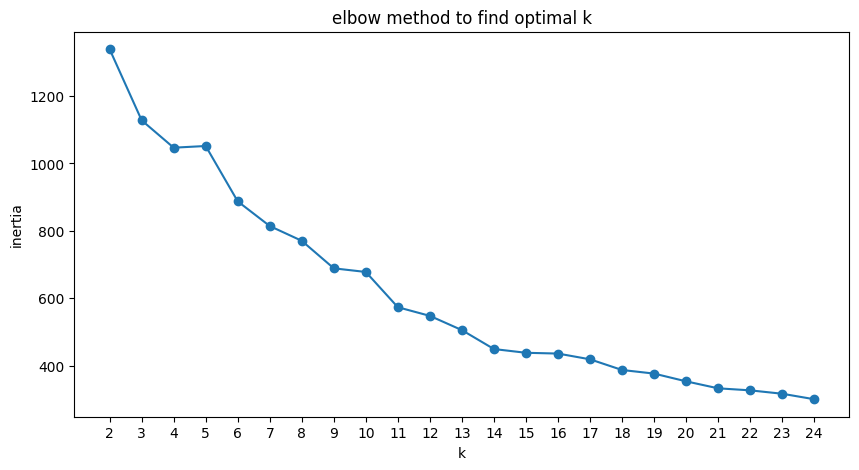

In [19]:
inertia = [] #track how tight clusters are
k_range = range(2, 25)

#test out ks 
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

#plot inertia to find elbow point
plt.figure(figsize=(10,5))
plt.plot(k_range, inertia, marker="o")
plt.title("elbow method to find optimal k")
plt.xlabel("k")
plt.ylabel("inertia")
plt.xticks(k_range)
plt.show()

somewhere in k = [11, 14]

In [20]:
for k in [11, 14]:
    kmeans = KMeans(n_clusters=k, random_state=123)
    kmeans.fit(features)
    df[f"cluster_{k}"] = kmeans.labels_
    print(f"\n{k} clusters")
    print(df[f"cluster_{k}"].value_counts().sort_index())


11 clusters
cluster_11
0      82
1      87
2      99
3     128
4      76
5      79
6      87
7      71
8      89
9      11
10     77
Name: count, dtype: int64

14 clusters
cluster_14
0     82
1     30
2     74
3     94
4     45
5     79
6     87
7     71
8     89
9     11
10    77
11    31
12    57
13    59
Name: count, dtype: int64


k = 11 best 


In [21]:
kmeans = KMeans(n_clusters=11, random_state=123, n_init=10)
kmeans.fit(features)
df["cluster"] = kmeans.labels_

print(df["cluster"].value_counts().sort_index())

cluster
0     122
1      77
2      94
3      87
4      82
5      45
6      78
7      59
8      87
9      79
10     76
Name: count, dtype: int64


### PCA 

In [22]:
pca = PCA(n_components=2, random_state=123)
pca_features = pca.fit_transform(features)

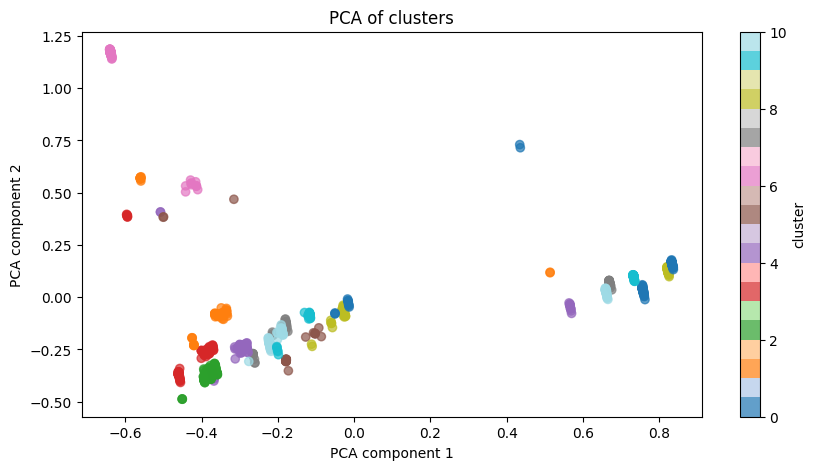

In [25]:
#plot PCA components colored by cluster
plt.figure(figsize=(10,5))
scatter = plt.scatter(
    pca_features[:,0], #x axis , first PCA component
    pca_features[:,1], #y axis, second PCA component
    c=df["cluster"],  # color by cluster assignment
    cmap="tab20", #20 distinct colors
    alpha=0.7
)
plt.colorbar(scatter, label="cluster")
plt.title("PCA of clusters")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.show()

look at each cluster 

In [29]:
for i in range(11):
    print(f"cluster {i}")
    cluster_books = df[df["cluster"] == i]
    print("subjects: ", cluster_books["subject"].value_counts().to_dict())
    print("categories: ", cluster_books["categories"].value_counts().to_dict())
    print("titles: ", cluster_books["title"].tolist()[:5]) 


cluster 0
subjects:  {'romance': 71, 'fiction': 49, 'biography': 2}
categories:  {'Fiction': 110, 'Juvenile Fiction': 3, 'Blindness': 1, 'College students': 1, 'Art dealers': 1, 'Romance fiction': 1, 'Large type books': 1, 'Classical literature': 1, 'Islands': 1, 'Canada': 1, 'Abduction': 1}
titles:  ['The Dream of the Celt', 'The Natural', 'Journey to the Center of the Earth', 'Mysteries', "Cat's Cradle"]
cluster 1
subjects:  {'nonfiction': 77}
categories:  {'Biography & Autobiography': 12, 'History': 8, 'Business & Economics': 7, 'Juvenile Nonfiction': 5, 'Unknown': 5, 'Nature': 4, 'Cooking': 3, 'Science': 3, 'Health & Fitness': 3, 'Body, Mind & Spirit': 2, 'Family & Relationships': 2, 'Medical': 2, 'Fiction': 2, 'Philosophy': 2, 'Gardening': 2, 'Social Science': 2, 'Education': 1, 'BIOGRAPHY & AUTOBIOGRAPHY': 1, 'Computers': 1, 'Mathematics': 1, 'Critical thinking': 1, 'Art': 1, 'Travel': 1, 'Photography': 1, 'Jungian psychology': 1, 'Capital punishment': 1, 'Self-Help': 1, 'Musical

#### Save Model 

In [ ]:
import joblib

#save model 
joblib.dump(kmeans, "../data/kmeans_model.pkl")

#save feature matrix column names 
joblib.dump(features.columns.tolist(), "../data/feature_columns.pkl")

#save scalar for page count and publish year 
joblib.dump(scaler, "../data/scaler.pkl")

#save clustered data
df.to_csv("../data/books.csv", index=False)


